![Alt text](image1.png)

# How Supervised Learning Works: Rat, Dog, or Lion?



In **supervised learning**, we show a model many examples where we already know the answer. The model learns the pattern that connects the *features* (what we measure) to the *label* (the correct answer). Then we give it **new, unseen data** and it predicts the label.

This notebook walks through each box in the diagram above:

1. **Labeled Data**: animals described by numbers (weight, height, ...)
2. **Labels**: the correct answer for each animal (Rat, Dog, Lion)
3. **Model Training**: the algorithm learns from data + labels
4. **Test Data**: animals the model has never seen
5. **Prediction**: the model decides Rat, Dog, or Lion

## Step 0: Import libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

np.random.seed(42)  # so everyone gets the same results

## Step 1: Create the Labeled Data

A computer can't "look" at a cartoon lion the way we do. It needs **numbers**. So we describe each animal with features:

| Feature | Meaning |
|---|---|
| `weight_kg` | body weight in kilograms |
| `height_cm` | shoulder height in centimeters |
| `tail_to_body` | tail length divided by body length |

We generate 50 examples of each animal with realistic, slightly random values.

In [29]:
def make_animals(name, n, weight, height, tail):
    """Create n animals with features drawn around (mean, std) values."""
    return pd.DataFrame({
        "weight_kg":    np.abs(np.random.normal(*weight, n)),
        "height_cm":    np.abs(np.random.normal(*height, n)),
        "tail_to_body": np.abs(np.random.normal(*tail, n)),
        "animal":       name,
    })

#                          name    n    weight(mean,std)  height(mean,std)  tail ratio
rats  = make_animals("Rat",  50, (0.35, 0.10),   (8, 2),     (0.95, 0.10))
dogs  = make_animals("Dog",  50, (25, 10),       (55, 12),   (0.35, 0.08))
lions = make_animals("Lion", 50, (190, 30),      (110, 10),  (0.45, 0.06))
spiders = make_animals("spider", 50, (56, 89),      (5, 10),  (0.20, 0.12))


data = pd.concat([rats, dogs, lions, spiders], ignore_index=True).sample(frac=1, random_state=42)
data.head(10)

,weight_kg,height_cm,tail_to_body,animal
95,28.853174,50.985985,0.294567,Dog
15,0.293771,10.712480,0.980155,Rat
30,0.289829,7.560656,0.794934,Rat
158,6.725212,5.485216,0.247334,spider
128,208.723595,131.898029,0.513505,Lion
115,190.630115,105.987795,0.405091,Lion
69,17.462638,55.982490,0.360459,Dog
170,31.520399,11.694053,0.202210,spider
174,202.402127,2.632592,0.299529,spider
45,0.278016,5.072970,1.028182,Rat


## Step 2: Separate Features (X) and Labels (y)

This is the split shown on the left of the diagram:
- **X** = the *Labeled Data* box (what the model sees)
- **y** = the *Labels* box (the correct answers)

In [30]:
X = data[["weight_kg", "height_cm", "tail_to_body"]]   # features
y = data["animal"]                                     # labels

print("Features shape:", X.shape)
print("\nHow many of each label:")
print(y.value_counts())

Features shape: (200, 3)

How many of each label:
animal
Dog       50
Rat       50
spider    50
Lion      50
Name: count, dtype: int64


### Let's look at the data
Each dot is one animal. Notice how the three groups sit in different regions. That separation is exactly what the model will learn.

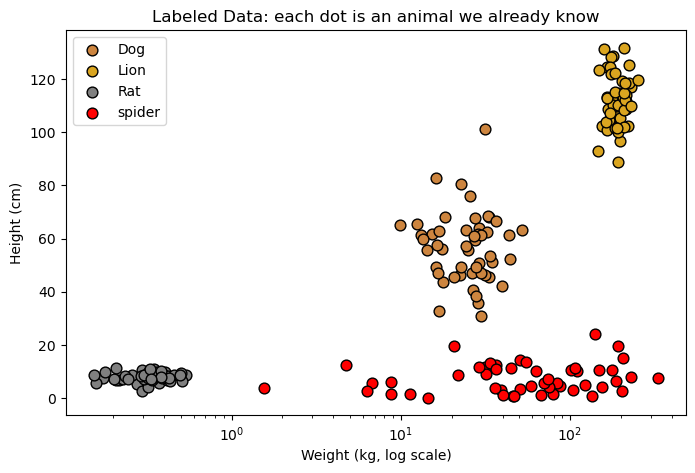

In [31]:
colors = {"Rat": "gray", "Dog": "peru", "Lion": "goldenrod", "spider": "red"}

fig, ax = plt.subplots(figsize=(8, 5))
for animal, group in data.groupby("animal"):
    ax.scatter(group["weight_kg"], group["height_cm"],
               label=animal, color=colors[animal], edgecolor="k", s=60)
ax.set_xscale("log")  # log scale because a lion is ~500x heavier than a rat
ax.set_xlabel("Weight (kg, log scale)")
ax.set_ylabel("Height (cm)")
ax.set_title("Labeled Data: each dot is an animal we already know")
ax.legend()
plt.show()

## Step 3: Split into Training Data and Test Data

We hide 30% of the animals from the model. Those become the **Test Data** box in the diagram, which lets us check whether the model really learned, or just memorized.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Training animals: {len(X_train)}")
print(f"Test animals:     {len(X_test)}  (the model never sees these during training)")

Training animals: 140
Test animals:     60  (the model never sees these during training)


## Step 4: Model Training ⚙️

We use a **Decision Tree**, a model that learns a series of yes/no questions, much like a game of *20 Questions*. It is easy to read, so we can see exactly what it learned.

In [33]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)   # <-- this single line is "Model Training"
print("Training complete!")

Training complete!


### What did the model learn?
Each box is a question. Follow the arrows (left = True, right = False) until you reach a final answer.

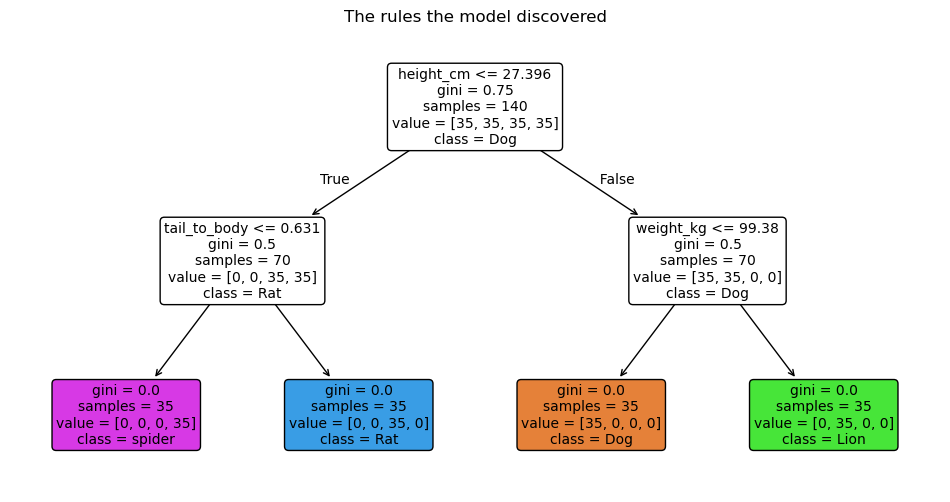

In [34]:
plt.figure(figsize=(12, 6))
plot_tree(model, feature_names=X.columns, class_names=model.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("The rules the model discovered")
plt.show()

## Step 5: Prediction 💡

Now we give the model the **Test Data** and ask it to predict each animal.

In [35]:
y_pred = model.predict(X_test)

results = X_test.copy()
results["true_animal"] = y_test
results["predicted"] = y_pred
results["correct?"] = np.where(results["true_animal"] == results["predicted"], "✅", "❌")
results.head(10)

,weight_kg,height_cm,tail_to_body,true_animal,predicted,correct?
50,27.504929,59.293448,0.249129,Dog,Dog,✅
88,16.532063,47.058562,0.372479,Dog,Dog,✅
161,59.138456,4.497619,0.449048,spider,spider,✅
173,177.651810,10.705987,0.173708,spider,spider,✅
156,46.474298,0.923939,0.141487,spider,spider,✅
9,0.404256,9.951090,0.942555,Rat,Rat,✅
64,34.633761,51.216769,0.329795,Dog,Dog,✅
155,14.565682,0.128746,0.150575,spider,spider,✅
160,230.860537,7.704568,0.234773,spider,spider,✅
136,165.235084,113.417560,0.547717,Lion,Lion,✅


## Step 6: How well did it do?

Accuracy: 100%

              precision    recall  f1-score   support

         Dog       1.00      1.00      1.00        15
        Lion       1.00      1.00      1.00        15
         Rat       1.00      1.00      1.00        15
      spider       1.00      1.00      1.00        15

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



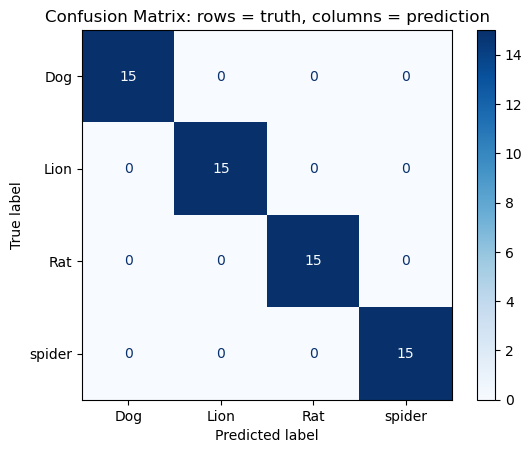

In [36]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.0%}\n")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix: rows = truth, columns = prediction")
plt.show()

## Step 7: Try it yourself! 🐾

Just like the diagram's *Test Data* box (a lion and a dog), describe a brand-new animal and let the model decide.
Change the numbers and re-run the cell.

In [37]:
def predict_animal(weight_kg, height_cm, tail_to_body):
    new_animal = pd.DataFrame([[weight_kg, height_cm, tail_to_body]], columns=X.columns)
    guess = model.predict(new_animal)[0]
    confidence = model.predict_proba(new_animal).max()
    print(f"{weight_kg} kg, {height_cm} cm, tail ratio {tail_to_body}  ->  {guess}  ({confidence:.0%} confident)")

predict_animal(180, 105, 0.45)   # like the lion in the Test Data box
predict_animal(20,  50,  0.30)   # like the dog in the Test Data box
predict_animal(0.3, 7,   1.00)   # a rat
predict_animal(80,  85,  0.40)   # a big dog or a small lion? You decide!

180 kg, 105 cm, tail ratio 0.45  ->  Lion  (100% confident)
20 kg, 50 cm, tail ratio 0.3  ->  Dog  (100% confident)
0.3 kg, 7 cm, tail ratio 1.0  ->  Rat  (100% confident)
80 kg, 85 cm, tail ratio 0.4  ->  Dog  (100% confident)


## Key Takeaways

| Diagram box | In the code |
|---|---|
| Labeled Data | `X` (weight, height, tail ratio) |
| Labels | `y` (Rat, Dog, Lion) |
| Model Training | `model.fit(X_train, y_train)` |
| Test Data | `X_test` (hidden during training) |
| Prediction | `model.predict(X_test)` |

**Discussion questions**
1. Why do we need the *labels*? What would happen if we trained without them? (Hint: look up *unsupervised learning*.)
2. The model could only answer Rat, Dog, or Lion. What would it predict for a **cat**? Why is that a problem?
3. Which feature did the tree use first? Why do you think that one is the most useful?
4. Try `max_depth=1`. What happens to accuracy, and why?

In [38]:
import os
os.makedirs("data", exist_ok=True) # safety net in case the folder is missing
# 1. Full labeled dataset (features + label)
data.to_csv("data/animals_full.csv", index=False)
# 2. Training data (what the model learned from)
train_df = X_train.copy()
train_df["animal"] = y_train
train_df.to_csv("data/train.csv", index=False)
# 3. Test data (hidden from the model during training)
test_df = X_test.copy()
test_df["animal"] = y_test
test_df.to_csv("data/test.csv", index=False)
# 4. Predictions on the test data
results.to_csv("data/predictions.csv", index=False)
print(os.listdir("data"))

['animals_full.csv', 'train.csv', 'test.csv', 'predictions.csv']


In [39]:
import joblib, json
from sklearn.metrics import accuracy_score
os.makedirs("models", exist_ok=True)
# 1. Save the trained Decision Tree
joblib.dump(model, "models/decision_tree.joblib")
# 2. Save a small "model card" with the facts about this model
model_info = {
"model": "DecisionTreeClassifier",
"max_depth": model.max_depth,
"features": list(X.columns),
"classes": list(model.classes_),
"train_size": len(X_train),
"test_size": len(X_test),
"test_accuracy": round(accuracy_score(y_test, y_pred), 3),
"random_state": 42,
}
with open("models/model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)
print(os.listdir("models"))
print(json.dumps(model_info, indent=2))

['decision_tree.joblib', 'model_info.json']
{
  "model": "DecisionTreeClassifier",
  "max_depth": 3,
  "features": [
    "weight_kg",
    "height_cm",
    "tail_to_body"
  ],
  "classes": [
    "Dog",
    "Lion",
    "Rat",
    "spider"
  ],
  "train_size": 140,
  "test_size": 60,
  "test_accuracy": 1.0,
  "random_state": 42
}


In [40]:
loaded_model = joblib.load("models/decision_tree.joblib")
new_animal = pd.DataFrame([[180, 105, 0.45]], columns=X.columns)
print("Loaded model predicts:", loaded_model.predict(new_animal)[0])

Loaded model predicts: Lion
